# Sale Price Prediction (Dubai Sales)
## Linear Regression vs Random Forest Regression

Goal: predict the **sale transaction value** using property, location, and transaction attributes.

Models compared:
- Linear Regression (baseline)
- Random Forest Regressor (nonlinear ensemble)

Target:
- `actual_worth` (log-transformed to reduce skewness)

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")

## 2. Load Dataset and Quick Inspection

In [2]:
df = pd.read_csv("clean_transactions_pandas.csv")

print("Original shape:", df.shape)
print("\nColumns:\n", list(df.columns))

# Check missing values (top 10)
missing = df.isnull().sum().sort_values(ascending=False)
print("\nMissing values (top 10):\n", missing.head(10))

Original shape: (469409, 32)

Columns:
 ['transaction_id', 'procedure_id', 'trans_group_id', 'trans_group_en', 'procedure_name_en', 'instance_date', 'property_type_id', 'property_type_en', 'property_sub_type_id', 'property_sub_type_en', 'property_usage_en', 'reg_type_id', 'reg_type_en', 'area_id', 'area_name_en', 'building_name_en', 'project_number', 'project_name_en', 'master_project_en', 'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en', 'rooms_en', 'has_parking', 'procedure_area', 'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price', 'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3']

Missing values (top 10):
 meter_rent_price        458999
rent_value              458999
nearest_mall_en         140949
nearest_metro_en        138256
building_name_en        134726
project_number          130253
project_name_en         130253
rooms_en                101080
property_sub_type_id     94499
property_sub_type_en     94499
dtype: int64


## 3. Filter Sales Transactions and Core Cleaning

Regression is performed only on completed Sales transactions.
Rows missing target (`actual_worth`) or key structural attribute (`procedure_area`) are removed.

In [3]:
# Keep only Sales
df = df[df["trans_group_en"] == "Sales"].copy()
print("After filtering Sales:", df.shape)

# Drop missing target or area
df = df.dropna(subset=["actual_worth", "procedure_area"])
print("After dropping missing actual_worth and procedure_area:", df.shape)

After filtering Sales: (359066, 32)
After dropping missing actual_worth and procedure_area: (359066, 32)


## 4. Feature Engineering (Time + Rooms)

- Extract transaction year and month.
- Convert `rooms_en` into numeric format.
- Prepare target transformation for regression.

In [4]:
# Convert date
df["instance_date"] = pd.to_datetime(df["instance_date"], errors="coerce")
df = df.dropna(subset=["instance_date"])

df["year"] = df["instance_date"].dt.year
df["month"] = df["instance_date"].dt.month

# Clean rooms
df["rooms_en"] = df["rooms_en"].astype(str)
df["rooms_clean"] = df["rooms_en"].str.extract(r"(\d+)")
df.loc[df["rooms_en"].str.contains("Studio", case=False, na=False), "rooms_clean"] = 0
df["rooms_clean"] = pd.to_numeric(df["rooms_clean"], errors="coerce")

print("Unique cleaned room values:")
print(sorted(df["rooms_clean"].dropna().unique()))
print("Current shape:", df.shape)

Unique cleaned room values:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(9.0)]
Current shape: (359066, 35)


In [7]:
df[[
    "procedure_area",
    "rooms_clean",
    "has_parking",
    "property_type_en",
    "property_usage_en",
    "area_name_en",
    "reg_type_en",
    "year",
    "month",
    "actual_worth"
]].head()

,procedure_area,rooms_clean,has_parking,property_type_en,property_usage_en,area_name_en,reg_type_en,year,month,actual_worth
5,211.37,NaN,0,Building,Residential,Al Karama,Existing Properties,2025,9,7000000.0
9,211.35,NaN,0,Building,Residential,Al Karama,Existing Properties,2023,8,5000000.0
13,272.21,NaN,0,Building,Residential,Al Raffa,Existing Properties,2002,4,1000000.0
14,5171.22,NaN,0,Building,Residential / Commercial,Al Hamriya,Existing Properties,2025,5,73500000.0
16,232.26,NaN,0,Villa,Residential,Al Satwa,Existing Properties,2005,10,1500000.0


## 5. Target Distribution Analysis

Real estate transaction prices are typically highly right-skewed due to the presence of extreme high-value properties.

We first examine the distribution of the raw target variable (`actual_worth`) to assess skewness and the presence of outliers. The degree of skewness is quantified numerically.

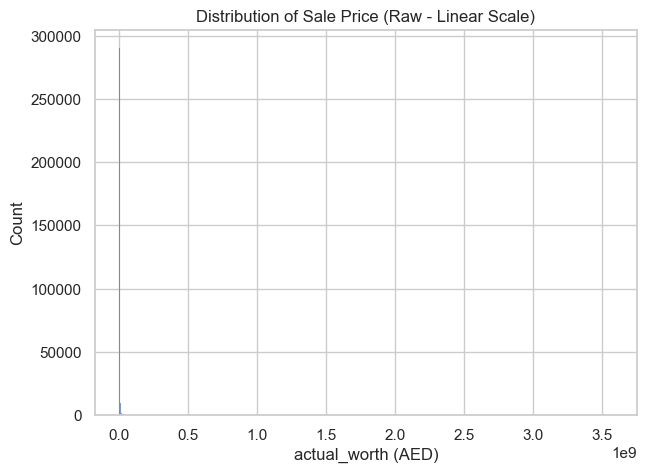

Raw price skewness: 105.26502745055744


In [5]:
plt.figure(figsize=(7,5))
sns.histplot(df["actual_worth"])
plt.title("Distribution of Sale Price (Raw - Linear Scale)")
plt.xlabel("actual_worth (AED)")
plt.show()

print("Raw price skewness:", df["actual_worth"].skew())

The distribution is heavily right-skewed, with most transactions concentrated at lower price ranges and a small number of extremely high-value outliers extending the tail.

The skewness value confirms severe asymmetry in the target variable.

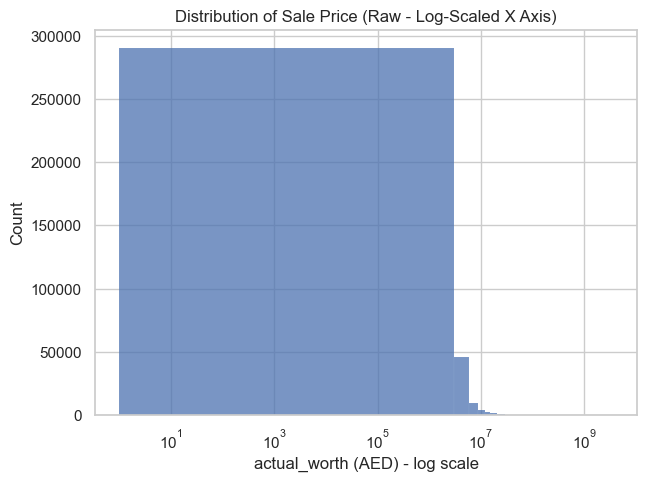

Raw price skewness: 105.26502745055744


In [6]:
plt.figure(figsize=(7,5))
sns.histplot(df["actual_worth"])
plt.xscale("log")
plt.title("Distribution of Sale Price (Raw - Log-Scaled X Axis)")
plt.xlabel("actual_worth (AED) - log scale")
plt.show()

print("Raw price skewness:", df["actual_worth"].skew())

Applying a logarithmic scale to the x-axis improves visualization by compressing the long right tail and revealing the spread of transactions across multiple orders of magnitude.

Note that this scaling improves interpretability but does not alter the underlying skewness of the data.

## 6. Log Transformation of Target Variable

To reduce skewness and stabilize variance, a logarithmic transformation is applied to the target variable.

Log transformation is commonly used in real estate valuation to mitigate the impact of extreme outliers and improve the suitability of linear modeling assumptions.

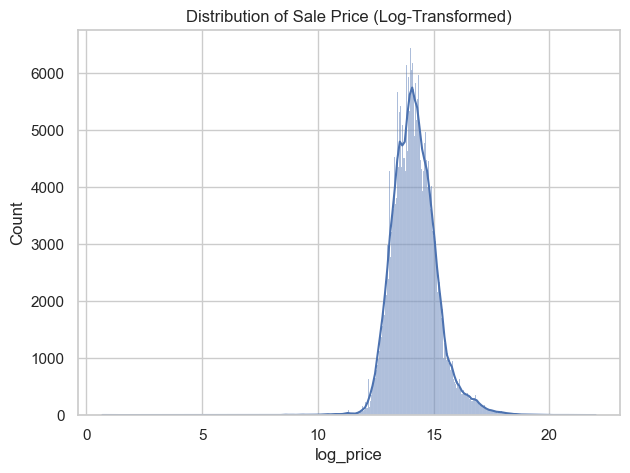

Log-transformed skewness: 0.4693076133956922


In [7]:
# Log-transform target
df["log_price"] = np.log1p(df["actual_worth"])

plt.figure(figsize=(7,5))
sns.histplot(df["log_price"], kde=True)
plt.title("Distribution of Sale Price (Log-Transformed)")
plt.xlabel("log_price")
plt.show()

print("Log-transformed skewness:", df["log_price"].skew())

The logarithmic transformation substantially reduces skewness and produces a distribution that is closer to symmetric.

This transformation improves numerical stability and supports more reliable performance of linear regression models.

## 7. Feature Selection for Regression

Selected features include structural, temporal, and categorical location attributes.

Rows with missing `rooms_clean` are removed to ensure consistent numeric representation.

In [8]:
features = [
    "procedure_area",
    "rooms_clean",
    "has_parking",
    "property_type_en",
    "property_usage_en",
    "area_name_en",
    "reg_type_en",
    "year",
    "month"
]

df_model = df[features + ["log_price"]].copy()

print("Before dropna:", df_model.shape)
print("\nMissing values:\n", df_model.isnull().sum())

df_model = df_model.dropna()
print("\nAfter dropna:", df_model.shape)

Before dropna: (359066, 10)

Missing values:
 procedure_area           0
rooms_clean          75534
has_parking              0
property_type_en         0
property_usage_en        0
area_name_en             0
reg_type_en              0
year                     0
month                    0
log_price                0
dtype: int64

After dropna: (283532, 10)


## 8. Train/Test Split

Data is split into training (80%) and testing (20%) sets.

No stratification is used since the target variable is continuous.

In [9]:
X = df_model[features]
y = df_model["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (226825, 9)
Testing shape: (56707, 9)


## 9. Preprocessing Setup

Categorical features are one-hot encoded.
Numeric features are passed through.

Scaling will be applied only for Linear Regression.

In [10]:
categorical_features = [
    "property_type_en",
    "property_usage_en",
    "area_name_en",
    "reg_type_en"
]

numeric_features = [
    "procedure_area",
    "rooms_clean",
    "has_parking",
    "year",
    "month"
]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

## 10. Model 1: Linear Regression

In [11]:
lr_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("scale", StandardScaler(with_mean=False)),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results:")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

Linear Regression Results:
MAE: 0.26955530540253547
RMSE: 0.3892265092851353
R2: 0.766279651451811


## 11. Model 2: Random Forest Regressor

In [12]:
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results:")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest Results:
MAE: 0.13923257931793517
RMSE: 0.2609468004582524
R2: 0.8949500971713333


## 12. Model Comparison Summary

In [13]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2": [lr_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,0.269555,0.389227,0.76628
1,Random Forest,0.139233,0.260947,0.89495


In [14]:
# % Performance Improvement: Random Forest vs Linear Regression
# Positive % means RF is better (lower error or higher R2)

lr_mae, lr_rmse, lr_r2 = lr_mae, lr_rmse, lr_r2
rf_mae, rf_rmse, rf_r2 = rf_mae, rf_rmse, rf_r2

mae_reduction_pct = (lr_mae - rf_mae) / lr_mae * 100
rmse_reduction_pct = (lr_rmse - rf_rmse) / lr_rmse * 100
r2_improvement_pct = (rf_r2 - lr_r2) / lr_r2 * 100

print("Random Forest vs Linear Regression Improvements:")
print(f"MAE reduction:  {mae_reduction_pct:.2f}%")
print(f"RMSE reduction: {rmse_reduction_pct:.2f}%")
print(f"R2 increase:    {r2_improvement_pct:.2f}%")

Random Forest vs Linear Regression Improvements:
MAE reduction:  48.35%
RMSE reduction: 32.96%
R2 increase:    16.79%


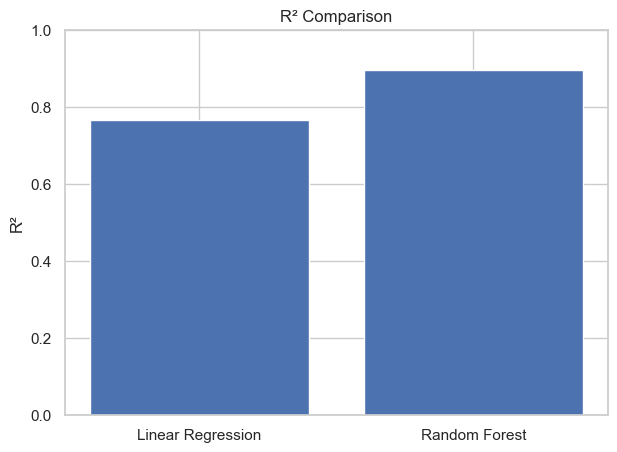

In [15]:
plt.figure(figsize=(7,5))
plt.bar(results["Model"], results["R2"])
plt.title("R² Comparison")
plt.ylabel("R²")
plt.ylim(0,1)
plt.show()

## 13. Cross-Validation (Model Stability)

5-fold cross-validation is used to evaluate model generalization stability.

In [16]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

lr_cv = cross_val_score(lr_pipeline, X, y, cv=cv, scoring="r2")
rf_cv = cross_val_score(rf_pipeline, X, y, cv=cv, scoring="r2")

print("Linear Regression CV R2: mean =", lr_cv.mean(), ", std =", lr_cv.std())
print("Random Forest CV R2: mean =", rf_cv.mean(), ", std =", rf_cv.std())

Linear Regression CV R2: mean = 0.7738870799958717 , std = 0.004085031557648668
Random Forest CV R2: mean = 0.9024184478961048 , std = 0.003856851992652792


### Linear Regression: Predicted vs Actual (Log Scale)

This plot compares predicted and actual log-transformed sale prices. Perfect predictions would lie on the diagonal line. The Linear Regression predictions are more scattered around the line, showing that the model does not capture all patterns in the data.

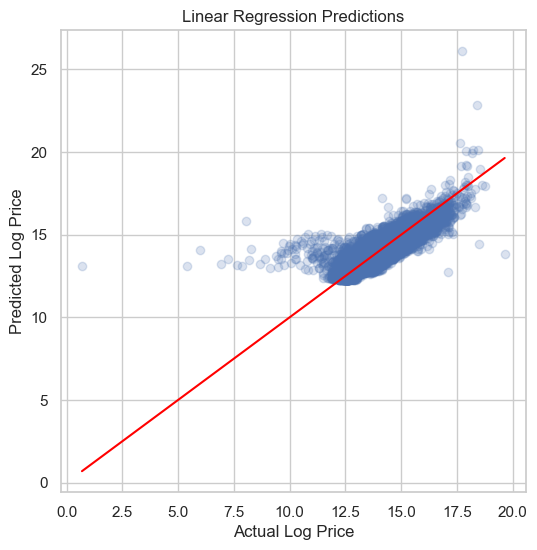

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, lr_pred, alpha=0.2)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Linear Regression Predictions")
plt.show()

### Random Forest: Predicted vs Actual (Log Scale)

This plot shows the same comparison for the Random Forest model. Predictions are closer to the diagonal line, indicating that Random Forest estimates the log-transformed sale price more accurately.

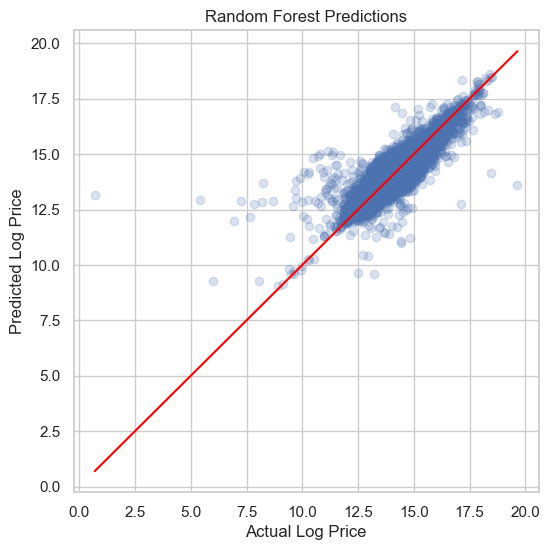

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred, alpha=0.2)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Random Forest Predictions")
plt.show()

## 14. Feature Importance Analysis

We extract:
- Impurity-based feature importance from Random Forest
- Absolute coefficient magnitude from Linear Regression

This helps identify the strongest drivers of pricing behavior.

In [19]:
# Extract feature names after preprocessing
ohe = rf_pipeline.named_steps["preprocess"].named_transformers_["cat"]
ohe_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([ohe_feature_names, numeric_features])

rf_model = rf_pipeline.named_steps["model"]

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

rf_importance.head(15)

procedure_area                                    0.607962
year                                              0.097968
area_name_en_Al Warsan First                      0.044606
area_name_en_Burj Khalifa                         0.026314
month                                             0.024012
reg_type_en_Existing Properties                   0.019487
area_name_en_Marsa Dubai                          0.016426
area_name_en_Business Bay                         0.015979
rooms_clean                                       0.012560
has_parking                                       0.009701
area_name_en_Palm Jumeirah                        0.009385
area_name_en_Al Barsha South Fourth               0.008696
reg_type_en_Off-Plan Properties                   0.008506
property_usage_en_Hospitality                     0.006387
area_name_en_Hadaeq Sheikh Mohammed Bin Rashid    0.005301
dtype: float64

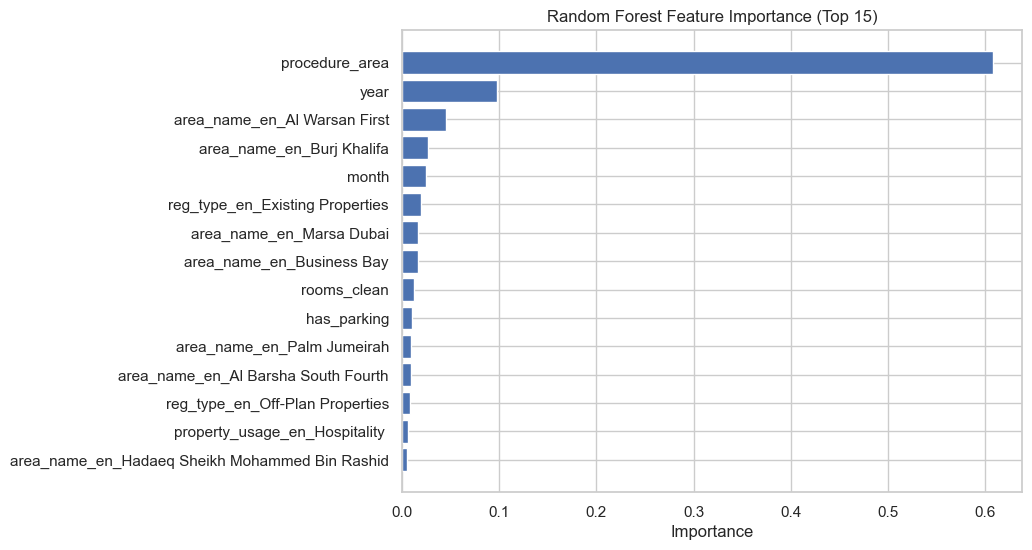

In [20]:
top15 = rf_importance.head(15).sort_values()

plt.figure(figsize=(8,6))
plt.barh(top15.index, top15.values)
plt.title("Random Forest Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.show()

In [21]:
# Extract linear model
lr_model = lr_pipeline.named_steps["model"]

# Get feature names from the fitted preprocessor within the lr_pipeline
fitted_preprocess_lr = lr_pipeline.named_steps["preprocess"]
fitted_ohe_lr = fitted_preprocess_lr.named_transformers_["cat"]

ohe_feature_names_lr = fitted_ohe_lr.get_feature_names_out(categorical_features)

# Combine with numeric features for the LR pipeline
all_feature_names_lr = np.concatenate([ohe_feature_names_lr, numeric_features])

# Coefficients correspond to same feature order generated by lr_pipeline
lr_coefficients = pd.Series(
    lr_model.coef_,
    index=all_feature_names_lr
)

# Absolute importance
lr_importance = lr_coefficients.abs().sort_values(ascending=False)

lr_importance.head(15)

rooms_clean                            0.400707
year                                   0.179307
procedure_area                         0.163744
area_name_en_Burj Khalifa              0.144994
area_name_en_Al Warsan First           0.115323
area_name_en_Marsa Dubai               0.106414
area_name_en_Palm Jumeirah             0.105308
area_name_en_Al Barsha South Fourth    0.072740
area_name_en_Business Bay              0.070549
area_name_en_Wadi Al Safa 5            0.068591
area_name_en_Al Yelayiss 2             0.058466
reg_type_en_Off-Plan Properties        0.055443
reg_type_en_Existing Properties        0.055443
area_name_en_Al Wasl                   0.053951
area_name_en_Madinat Al Mataar         0.051400
dtype: float64

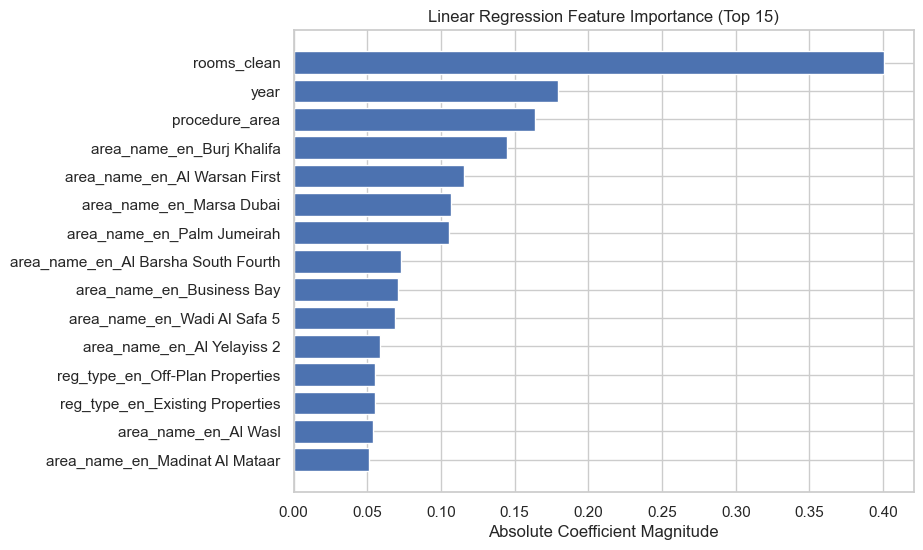

In [22]:
top15_lr = lr_importance.head(15).sort_values()

plt.figure(figsize=(8,6))
plt.barh(top15_lr.index, top15_lr.values)
plt.title("Linear Regression Feature Importance (Top 15)")
plt.xlabel("Absolute Coefficient Magnitude")
plt.show()

## 15. SHAP Explainability (Random Forest)

While impurity-based feature importance identifies the strongest predictors globally, it does not show how features influence individual predictions or the direction of their effect.

To provide stronger interpretability, SHAP (SHapley Additive exPlanations) values are computed for the Random Forest model.

SHAP quantifies each feature’s contribution to the predicted log sale price and enables both global and local interpretability.

In [19]:
!pip install shap

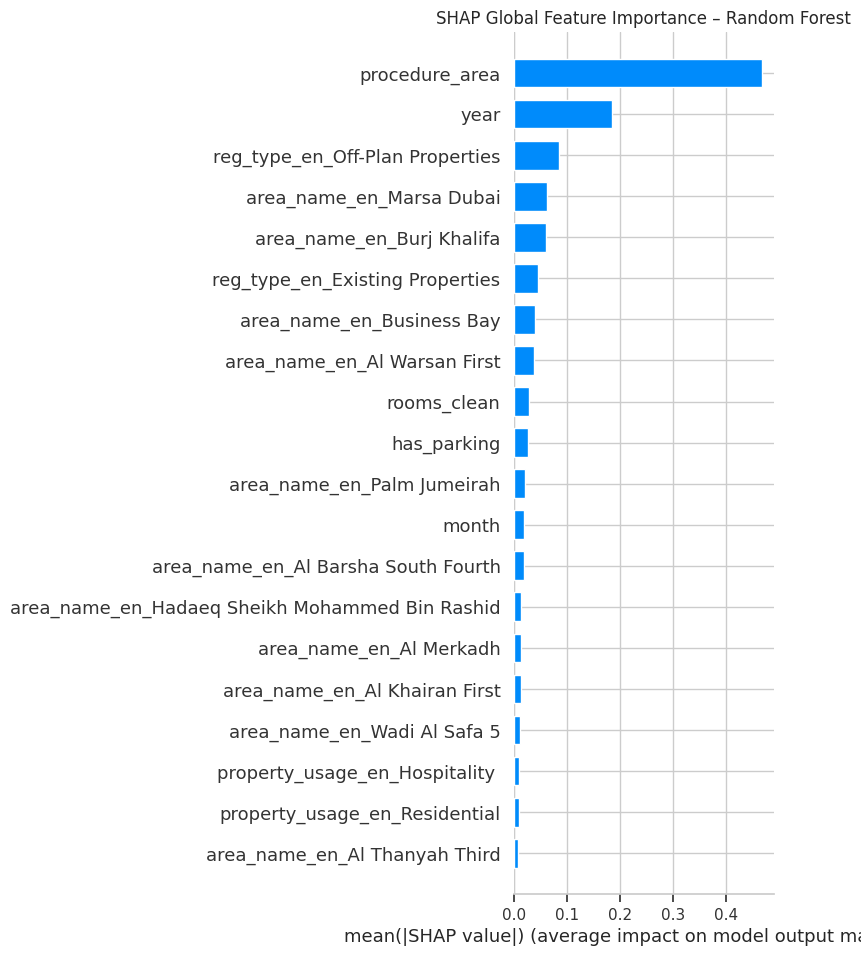

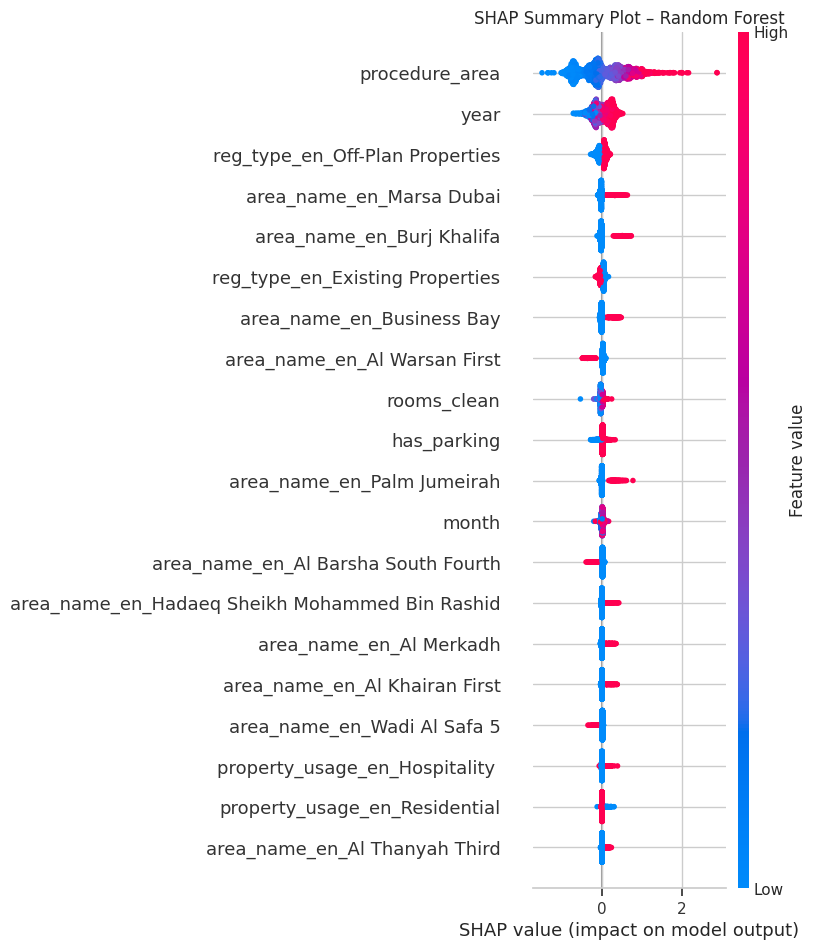

In [20]:
import shap
import scipy.sparse as sp

# Sample for computational efficiency
X_shap = X_test.sample(n=3000, random_state=42)

# Transform using fitted preprocessing
X_shap_trans = rf_pipeline.named_steps["preprocess"].transform(X_shap)

# Convert sparse matrix if needed
if sp.issparse(X_shap_trans):
    X_shap_trans = X_shap_trans.toarray()

rf_model = rf_pipeline.named_steps["model"]

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap_trans)

# Global feature importance (bar plot)
shap.summary_plot(
    shap_values,
    X_shap_trans,
    feature_names=all_feature_names,
    plot_type="bar",
    show=False
)
plt.title("SHAP Global Feature Importance – Random Forest")
plt.show()

# Detailed impact distribution (beeswarm)
shap.summary_plot(
    shap_values,
    X_shap_trans,
    feature_names=all_feature_names,
    show=False
)
plt.title("SHAP Summary Plot – Random Forest")
plt.show()

## 16. Interpretation of Pricing Drivers

SHAP analysis confirms that structural property characteristics are the primary determinants of sale price.

Both impurity-based feature importance and SHAP values identify `procedure_area` as the dominant driver of pricing predictions. Larger property area consistently increases predicted log price.

Temporal effects (`year`) also contribute positively, reflecting market appreciation trends over time.

Premium location indicators (e.g., Burj Khalifa, Palm Jumeirah) exhibit strong positive SHAP contributions, confirming localized price premiums.

These findings demonstrate that property size, transaction timing, and location-specific demand are the strongest drivers of real estate valuation in Dubai.